In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
sentiment = pd.read_csv('data/fear_greed_index.csv')
print("Sentiment data shape:", sentiment.shape)
sentiment.head()

trades = pd.read_csv('data/historical_data.csv')
print("Trades data shape:", trades.shape)
trades.head()

Sentiment data shape: (2644, 4)
Trades data shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
# Convert numeric columns
numeric_cols = ['Size USD', 'Closed PnL', 'Execution Price', 'size']
for col in numeric_cols:
    if col in trades.columns:
        trades[col] = pd.to_numeric(trades[col], errors='coerce')

# Convert timestamps
trades['timestamp'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
trades['date'] = trades['timestamp'].dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

# Drop missing values
trades = trades.dropna(subset=['Closed PnL', 'date'])
sentiment = sentiment.dropna(subset=['classification', 'value'])

In [7]:
# Aggregate daily metrics
daily_metrics = trades.groupby('date').agg({
    'Closed PnL': ['sum', 'mean', 'count'],
    'Size USD': ['sum', 'mean']
}).round(2)

daily_metrics.columns = ['total_pnl', 'avg_pnl', 'trade_count', 'total_volume', 'avg_trade_size']
daily_metrics = daily_metrics.reset_index()

# Merge with sentiment
merged = pd.merge(daily_metrics, sentiment[['date', 'classification', 'value']], on='date', how='inner')
print(f"Merged data has {len(merged)} days")
merged.head()

Merged data has 479 days


,date,total_pnl,avg_pnl,trade_count,total_volume,avg_trade_size,classification,value
0,2023-05-01,0.00,0.00,3,477.00,159.00,Greed,63
1,2023-12-05,0.00,0.00,9,50005.83,5556.20,Extreme Greed,75
2,2023-12-14,-205.43,-18.68,11,113203.35,10291.21,Greed,72
3,2023-12-15,-24.63,-12.32,2,10609.95,5304.98,Greed,70
4,2023-12-16,0.00,0.00,3,15348.77,5116.26,Greed,67


classification
Greed            193
Extreme Greed    114
Fear              91
Neutral           67
Extreme Fear      14
Name: count, dtype: int64


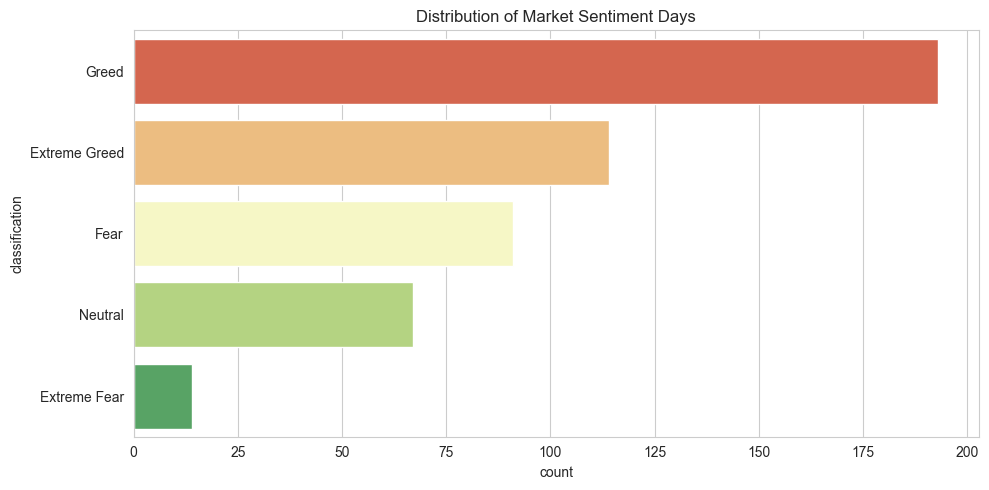

               total_pnl             avg_pnl trade_count total_volume
                    mean         sum    mean        mean         mean
classification                                                       
Extreme Fear    52793.59   739110.24   38.43     1528.57   8177447.25
Extreme Greed   23817.29  2715171.34   56.74      350.81   1091799.69
Fear            36891.82  3357155.42   31.28      679.53   5311261.43
Greed           11140.57  2150129.31   39.41      260.64   1495246.09
Neutral         19297.32  1292920.67   63.82      562.48   2690180.05


In [8]:
# Distribution
sentiment_counts = merged['classification'].value_counts()
print(sentiment_counts)

plt.figure(figsize=(10, 5))
sns.countplot(data=merged, y='classification', order=sentiment_counts.index, palette='RdYlGn')
plt.title('Distribution of Market Sentiment Days')
plt.tight_layout()
plt.savefig('outputs/sentiment_distribution.png')
plt.show()

# Performance by sentiment
performance_by_sentiment = merged.groupby('classification').agg({
    'total_pnl': ['mean', 'sum'],
    'avg_pnl': 'mean',
    'trade_count': 'mean',
    'total_volume': 'mean'
}).round(2)
print(performance_by_sentiment)

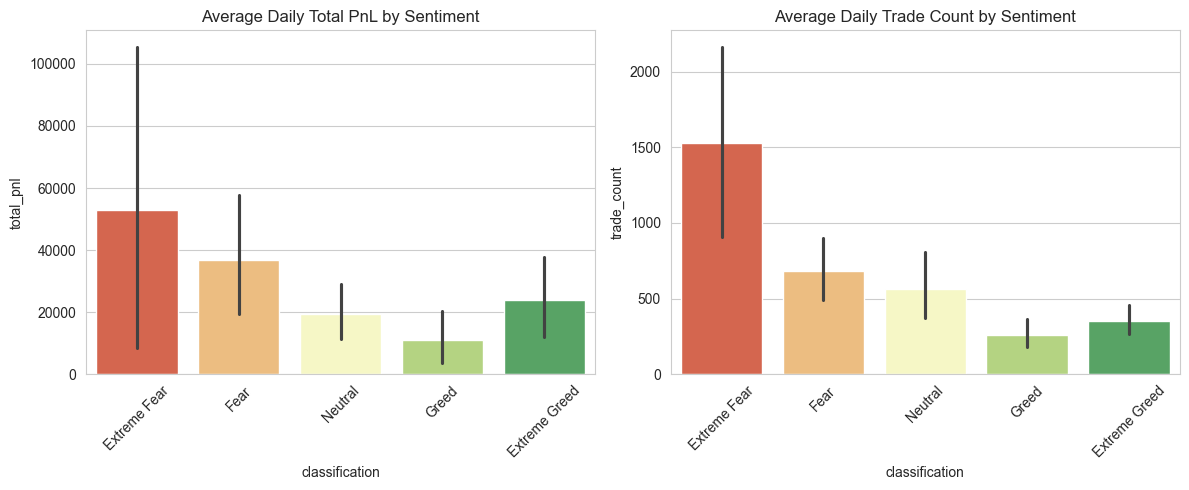

ANOVA: F-statistic = 2.7913, p-value = 0.0259


In [9]:
# PnL and Trade Count by Sentiment
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=merged, x='classification', y='total_pnl', 
            order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'],
            palette='RdYlGn')
plt.title('Average Daily Total PnL by Sentiment')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.barplot(data=merged, x='classification', y='trade_count',
            order=['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'],
            palette='RdYlGn')
plt.title('Average Daily Trade Count by Sentiment')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('outputs/performance_by_sentiment.png')
plt.show()

# ANOVA test
groups = [merged[merged['classification'] == cat]['total_pnl'].dropna() 
          for cat in ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']]
f_stat, p_value = stats.f_oneway(*groups)
print(f"ANOVA: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")

Available columns in trades: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'timestamp', 'date']

Using column 'Side' for trade direction
Unique values: <StringArray>
['BUY', 'SELL']
Length: 2, dtype: str
Trades with valid direction: 211224 out of 211224

Buy ratio by sentiment:
 classification
Extreme Fear     0.486538
Extreme Greed    0.456803
Fear             0.513495
Greed            0.493477
Neutral          0.499824
Name: buy_ratio, dtype: float64

Using column 'Account' for trader identification

Top 10 traders by total PnL:
 Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.36080

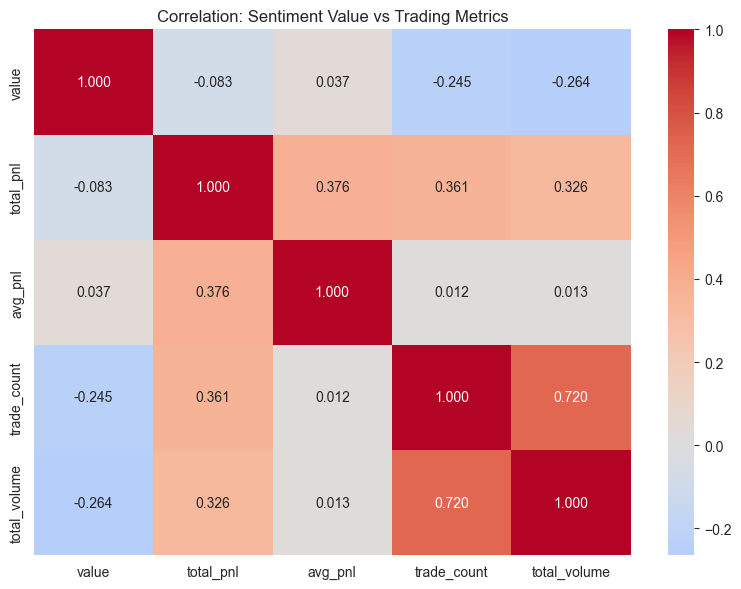


✅ Analysis complete!

DATA SUMMARY
Total trades: 211224
Total days in merged data: 479
Sentiment categories present: <StringArray>
['Greed', 'Extreme Greed', 'Neutral', 'Fear', 'Extreme Fear']
Length: 5, dtype: str
Date range: 2023-05-01 to 2025-05-01


In [11]:
# First, check what columns are available
print("Available columns in trades:", trades.columns.tolist())

# Buy/Sell analysis - Check for side/position direction columns
# Look for any column that might indicate buy/sell/long/short
direction_column = None
for col in trades.columns:
    if 'side' in col.lower():
        direction_column = col
        break
    elif 'direction' in col.lower():
        direction_column = col
        break
    elif 'action' in col.lower():
        direction_column = col
        break
    elif 'type' in col.lower():
        direction_column = col
        break

if direction_column:
    print(f"\nUsing column '{direction_column}' for trade direction")
    print(f"Unique values: {trades[direction_column].unique()[:10]}")
    
    # Try to identify buy/long vs sell/short
    trades['is_buy'] = trades[direction_column].str.lower().map(
        lambda x: 1 if x in ['buy', 'long', 'b', 'l', 'open long', 'open buy'] 
        else 0 if x in ['sell', 'short', 's', 'close long', 'close buy', 'open short']
        else None
    )
    
    # Drop rows where direction couldn't be determined
    trades_with_direction = trades.dropna(subset=['is_buy'])
    print(f"Trades with valid direction: {len(trades_with_direction)} out of {len(trades)}")
    
    if len(trades_with_direction) > 0:
        # Daily buy ratio
        daily_buy_ratio = trades_with_direction.groupby('date')['is_buy'].mean().reset_index()
        daily_buy_ratio.columns = ['date', 'buy_ratio']
        
        # Merge with sentiment
        merged_with_direction = pd.merge(merged, daily_buy_ratio, on='date', how='left')
        print("\nBuy ratio by sentiment:\n", merged_with_direction.groupby('classification')['buy_ratio'].mean())
    else:
        print("⚠️ Could not determine buy/sell direction from available data")
        merged_with_direction = merged.copy()
        merged_with_direction['buy_ratio'] = None
else:
    print("⚠️ No direction column found (looking for: side, direction, action, type)")
    print("Skipping buy/sell analysis...")
    merged_with_direction = merged.copy()
    merged_with_direction['buy_ratio'] = None

# Top traders - Check for account/user column
account_column = None
for col in trades.columns:
    if 'account' in col.lower():
        account_column = col
        break
    elif 'user' in col.lower():
        account_column = col
        break
    elif 'trader' in col.lower():
        account_column = col
        break
    elif 'wallet' in col.lower():
        account_column = col
        break

if account_column:
    print(f"\nUsing column '{account_column}' for trader identification")
    
    # Top traders by total PnL
    trader_sentiment_pnl = pd.merge(
        trades[[account_column, 'Closed PnL', 'date']], 
        sentiment[['date', 'classification']], 
        on='date', 
        how='left'
    )
    
    top_traders = trader_sentiment_pnl.groupby(account_column)['Closed PnL'].sum().sort_values(ascending=False).head(10)
    print("\nTop 10 traders by total PnL:\n", top_traders)
    
    # Optional: Show how top traders perform in different sentiments
    if len(top_traders) > 0:
        top_trader_names = top_traders.index.tolist()
        trader_sentiment_summary = trader_sentiment_pnl[trader_sentiment_pnl[account_column].isin(top_trader_names)]\
            .groupby([account_column, 'classification'])['Closed PnL'].mean().unstack()
        print("\nTop traders performance across sentiments:")
        print(trader_sentiment_summary)
else:
    print("\n⚠️ No account column found (looking for: account, user, trader, wallet)")
    print("Skipping top traders analysis...")

# Correlation heatmap - This should work if merged dataframe has required columns
print("\n" + "="*50)
print("CORRELATION ANALYSIS")
print("="*50)

# Check which columns exist in merged dataframe
available_metrics = ['value']
for col in ['total_pnl', 'avg_pnl', 'trade_count', 'total_volume']:
    if col in merged.columns:
        available_metrics.append(col)
    else:
        print(f"⚠️ Column '{col}' not found in merged dataframe")

print(f"\nAvailable columns for correlation: {available_metrics}")

if len(available_metrics) >= 2:
    correlation_matrix = merged[available_metrics].corr()
    print("\nCorrelation matrix:")
    print(correlation_matrix.round(4))
    
    print("\nCorrelation with sentiment value:")
    if 'value' in correlation_matrix.columns:
        print(correlation_matrix['value'].round(4))
    
    # Create heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
    plt.title('Correlation: Sentiment Value vs Trading Metrics')
    plt.tight_layout()
    plt.savefig('outputs/correlation_heatmap.png')
    plt.show()
else:
    print("❌ Not enough columns for correlation analysis")

print("\n✅ Analysis complete!")

# Optional: Print summary of available data for debugging
print("\n" + "="*50)
print("DATA SUMMARY")
print("="*50)
print(f"Total trades: {len(trades)}")
print(f"Total days in merged data: {len(merged)}")
print(f"Sentiment categories present: {merged['classification'].unique()}")
print(f"Date range: {merged['date'].min()} to {merged['date'].max()}")